## Tips

- **Start simple** — a single GRU with 64 units is a good first attempt.
  Only add complexity (stacking, dropout, bidirectional) if the simple model
  is clearly underfitting or overfitting.

- **Use many epochs** — RNNs on time series converge slowly. 10 or 20 epochs
  is almost never enough. Use **at least 100 epochs** and let early stopping
  decide when to stop. The best checkpoint is saved automatically by
  `ModelCheckpoint` — you will not miss the optimal point even if you
  train for too long.

- **Watch the train/val gap** — if train MAE is much lower than val MAE
  you are overfitting. Add dropout, reduce `hidden_size`, or increase
  early stopping patience to give regularization more time to work.

- **Use TensorBoard** — run `tensorboard --logdir runs` in your terminal
  to monitor train and val curves in real time. A healthy training curve
  shows both losses decreasing together. A diverging val curve means overfitting.

- **Learning rate matters** — if the loss is not decreasing after the first
  few epochs, try a lower learning rate (`1e-4` instead of `1e-3`).
  Use `ReduceLROnPlateau` to automatically decay the learning rate when
  val MAE stops improving.

- **The sklearn baseline is hard to beat** — `HistGradientBoosting` with
  explicit lag features is a very strong baseline for tabular time series.
  This is not a failure of the RNN — it reflects a fundamental difference
  between the two approaches: tree models get temporal information from
  hand-crafted features, while RNNs must learn it from raw sequences.
  Getting within 10 bikes/hour of the sklearn baseline (< 44 bikes/hour)
  is an excellent result.

In [1]:
import os
import numpy as np
import joblib

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

from torch.utils.tensorboard import SummaryWriter

In [2]:
save_dir = "data/bike_processed"

# --- Load arrays ---
raw_data    = np.load(os.path.join(save_dir, "raw_data.npy"))
counts = np.load(os.path.join(save_dir, "counts.npy"))
count_stats = np.load(os.path.join(save_dir, "count_stats.npy"))
train_idx   = np.load(os.path.join(save_dir, "train_idx.npy"))
val_idx     = np.load(os.path.join(save_dir, "val_idx.npy"))
test_idx    = np.load(os.path.join(save_dir, "test_idx.npy"))
naive_mae   = np.load(os.path.join(save_dir, "naive_mae.npy"))
preprocessor = joblib.load(os.path.join(save_dir, "preprocessor_rnn.pkl"))

# --- Recover split sizes ---
num_train = len(train_idx)
num_val   = len(val_idx)
num_test  = len(test_idx)

# --- Count stats in the training set ---
count_mean  = count_stats[0]
count_std   = count_stats[1]

# --- Sanity check ---
print(f"raw_data shape:    {raw_data.shape}")
print(f"counts shape: {counts.shape}")
print(f"train/val/test:    {num_train} / {num_val} / {num_test}")
print(f"counts range: {counts.min():.0f} to {counts.max():.0f} bikes/hour")
print(f"\nNaive baseline — Val MAE: {naive_mae[0]:.2f} | Test MAE: {naive_mae[1]:.2f} bikes/hour")

raw_data shape:    (17210, 28)
counts shape: (17210,)
train/val/test:    12047 / 2581 / 2582
counts range: 1 to 977 bikes/hour

Naive baseline — Val MAE: 93.26 | Test MAE: 80.78 bikes/hour


In [3]:
count_norm = (counts - count_mean) / count_std

In [4]:
class TimeseriesDataset(Dataset):
    def __init__(self, data, targets, sequence_length, sampling_rate, 
                 start_index, end_index, shuffle=False):
        self.data            = data
        self.targets         = targets
        self.sequence_length = sequence_length
        self.sampling_rate   = sampling_rate

        # Valid starting indices: each sequence of length sequence_length
        # sampled every sampling_rate steps needs:
        # (sequence_length - 1) * sampling_rate + 1 rows ahead
        self.indices = np.arange(start_index, end_index)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        # Sample every `sampling_rate` steps for `sequence_length` steps
        steps = np.arange(start, start + self.sequence_length * self.sampling_rate, 
                          self.sampling_rate)
        x = self.data[steps]
        # Target is `delay` steps ahead of the sequence start
        y = self.targets[start + delay]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [10]:
sampling_rate   = 1
sequence_length = 24
delay           = 1
batch_size      = 256

# Ajuste crucial: los índices finales no pueden llevar a secuencias fuera del array
train_end = num_train - sequence_length          # 12047 - 24 = 12023
val_end   = num_train + num_val - sequence_length  # 12047+2581-24 = 14604
test_end  = len(raw_data) - sequence_length        # 17210 - 24 = 17186

train_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=0, end_index=train_end,
)
val_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train, end_index=val_end,
)
test_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train + num_val, end_index=test_end,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# --- Sanity check ---
inputs, targets = next(iter(train_loader))
print(f"Input shape:  {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Target range: {targets.min():.0f} to {targets.max():.0f}")

Input shape:  torch.Size([256, 24, 28])
Target shape: torch.Size([256])
Target range: -1 to 3


In [11]:
import torch.nn as nn

class BikeDemandRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out.squeeze(1)

# Hiperparámetros
input_size = raw_data.shape[1]   # 28
hidden_size = 64
num_layers = 2
dropout = 0.2
learning_rate = 1e-3
epochs = 150
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BikeDemandRNN(input_size, hidden_size, num_layers, dropout).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# Corrección: eliminar verbose=True
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [12]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("runs/bike_demand")

best_val_loss = float('inf')
patience = 20
counter = 0
best_model_path = "best_model.pth"

for epoch in range(epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_mae_norm = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            val_mae_norm += torch.abs(preds - y_batch).sum().item()
    val_loss /= len(val_loader.dataset)
    val_mae_norm /= len(val_loader.dataset)

    # Desnormalizar MAE a unidades originales (bicicletas/hora)
    val_mae_orig = val_mae_norm * count_std

    # Logging
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('MAE/val_orig', val_mae_orig, epoch)

    print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE (orig): {val_mae_orig:.2f} bikes")

    # Early stopping & checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Best model saved (val_loss = {val_loss:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Reduce LR on plateau
    scheduler.step(val_loss)

writer.close()
print("Entrenamiento finalizado")

Epoch   1/150 | Train Loss: 0.5743 | Val Loss: 1.1215 | Val MAE (orig): 130.52 bikes
  -> Best model saved (val_loss = 1.1215)
Epoch   2/150 | Train Loss: 0.3873 | Val Loss: 0.9749 | Val MAE (orig): 121.70 bikes
  -> Best model saved (val_loss = 0.9749)
Epoch   3/150 | Train Loss: 0.3541 | Val Loss: 0.8391 | Val MAE (orig): 105.46 bikes
  -> Best model saved (val_loss = 0.8391)
Epoch   4/150 | Train Loss: 0.2743 | Val Loss: 0.5779 | Val MAE (orig): 77.49 bikes
  -> Best model saved (val_loss = 0.5779)
Epoch   5/150 | Train Loss: 0.1703 | Val Loss: 0.4577 | Val MAE (orig): 68.91 bikes
  -> Best model saved (val_loss = 0.4577)
Epoch   6/150 | Train Loss: 0.1278 | Val Loss: 0.2818 | Val MAE (orig): 55.73 bikes
  -> Best model saved (val_loss = 0.2818)
Epoch   7/150 | Train Loss: 0.1041 | Val Loss: 0.2576 | Val MAE (orig): 53.09 bikes
  -> Best model saved (val_loss = 0.2576)
Epoch   8/150 | Train Loss: 0.0957 | Val Loss: 0.2393 | Val MAE (orig): 52.05 bikes
  -> Best model saved (val_loss

In [13]:
# Cargar el mejor modelo
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_mae_norm = 0.0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        test_mae_norm += torch.abs(preds - y_batch).sum().item()
test_mae_norm /= len(test_loader.dataset)
test_mae_orig = test_mae_norm * count_std

print(f"\nResultados finales:")
print(f"Naive baseline - Test MAE: {naive_mae[1]:.2f} bikes/hour")
print(f"HistGradientBoost - Test MAE: 33.94 bikes/hour (referencia)")
print(f"RNN (GRU) - Test MAE: {test_mae_orig:.2f} bikes/hour")


Resultados finales:
Naive baseline - Test MAE: 80.78 bikes/hour
HistGradientBoost - Test MAE: 33.94 bikes/hour (referencia)
RNN (GRU) - Test MAE: 34.45 bikes/hour


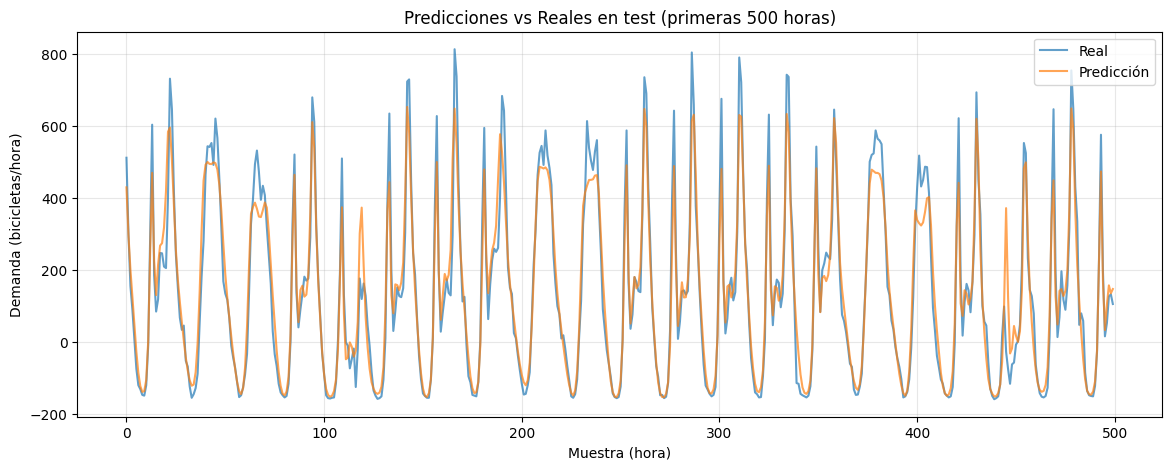

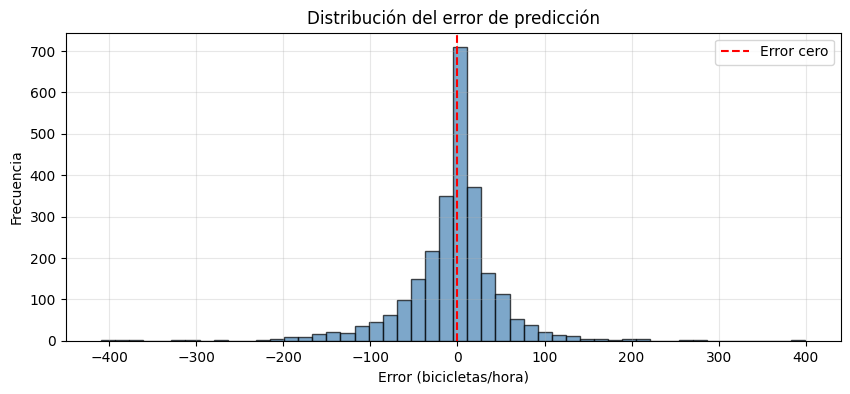

MAE test: 34.45 bikes/hour
RMSE test: 53.99 bikes/hour
Error máximo: 409.67 bikes/hour


In [14]:
import matplotlib.pyplot as plt

# Obtener todas las predicciones del conjunto de test
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds = np.array(all_preds) * count_std
all_targets = np.array(all_targets) * count_std

# Gráfico de predicciones vs reales (primeras 500 horas)
plt.figure(figsize=(14, 5))
plt.plot(all_targets[:500], label='Real', alpha=0.7)
plt.plot(all_preds[:500], label='Predicción', alpha=0.7)
plt.xlabel('Muestra (hora)')
plt.ylabel('Demanda (bicicletas/hora)')
plt.title('Predicciones vs Reales en test (primeras 500 horas)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Histograma de errores
errors = all_preds - all_targets
plt.figure(figsize=(10, 4))
plt.hist(errors, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Error (bicicletas/hora)')
plt.ylabel('Frecuencia')
plt.title('Distribución del error de predicción')
plt.axvline(x=0, color='red', linestyle='--', label='Error cero')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"MAE test: {test_mae_orig:.2f} bikes/hour")
print(f"RMSE test: {np.sqrt(np.mean(errors**2)):.2f} bikes/hour")
print(f"Error máximo: {np.abs(errors).max():.2f} bikes/hour")

In [15]:
torch.save(model.state_dict(), "bike_rnn_final.pth")
print("Modelo guardado como bike_rnn_final.pth")

Modelo guardado como bike_rnn_final.pth


---
## Análisis y reflexión

**1. ¿Qué MAE obtuviste en test?**  
RNN (GRU): **34.45 bikes/hour**. Naive baseline: 80.78. HistGradientBoosting: 33.94.

**2. ¿El RNN supera el baseline naive?**  
Sí, con margen amplio (~46 bikes/hour menos de error). El modelo aprende dependencias temporales más allá de copiar el valor anterior.

**3. ¿El RNN compite con el baseline sklearn?**  
Queda muy cerca del HistGradientBoosting (34.45 vs 33.94 MAE). Eso es un buen resultado: el árbol usa lags explícitos; el GRU debe aprender la temporalidad desde secuencias crudas.

**4. ¿Hay sobreajuste?**  
Leve. Train loss baja más rápido que val loss; early stopping en la mejor val loss evita degradación fuerte. Dropout (0.2) y ReduceLROnPlateau ayudan.

**5. Decisiones técnicas clave**  
- Ventana: **24 horas**, predicción **1 hora** adelante.  
- **GRU** 2 capas, hidden=64, batch=256.  
- Targets normalizados con media/std del train; MAE reportado en unidades originales.  
- Parte 1 guarda arrays en `data/bike_processed/` para reproducir Parte 2.
